# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
https://www.kaggle.com/datasets/shivam2503/diamonds

This classic dataset contains the prices and other attributes of almost 54,000 diamonds. It's a great dataset for beginners learning to work with data analysis and visualization.

Atribut:
*   price price in US dollars (\$326--\$18,823)
*   carat weight of the diamond (0.2--5.01)
*   cut quality of the cut (Fair, Good, Very Good, Premium, Ideal)
*   color diamond colour, from J (worst) to D (best)
*   clarity a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
*   x length in mm (0--10.74)
*   y width in mm (0--58.9)
*   z depth in mm (0--31.8)
*   depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
*   table width of top of diamond relative to widest point (43--95)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [14]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Pengaturan visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [16]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MSML/dataset/diamonds.csv')

In [17]:
# Tampilkan 5 baris pertama
print(df.head())

# Info dataset
print(df.info())

# Statistik deskriptif
print(df.describe())

   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing values per kolom:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


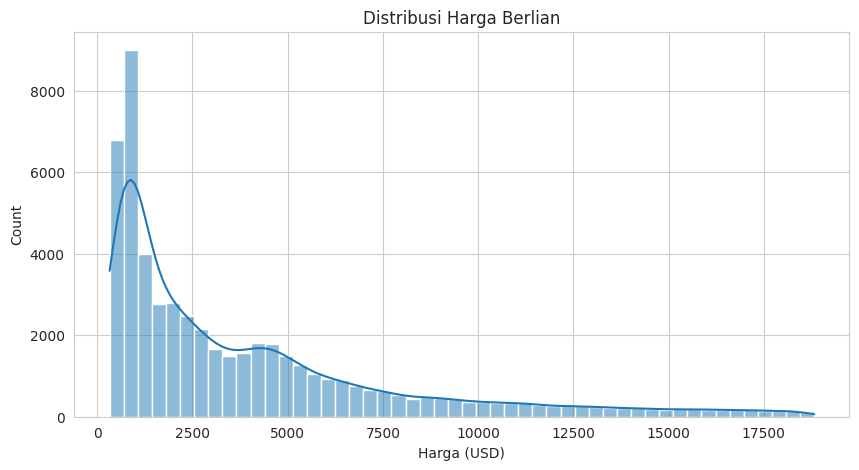

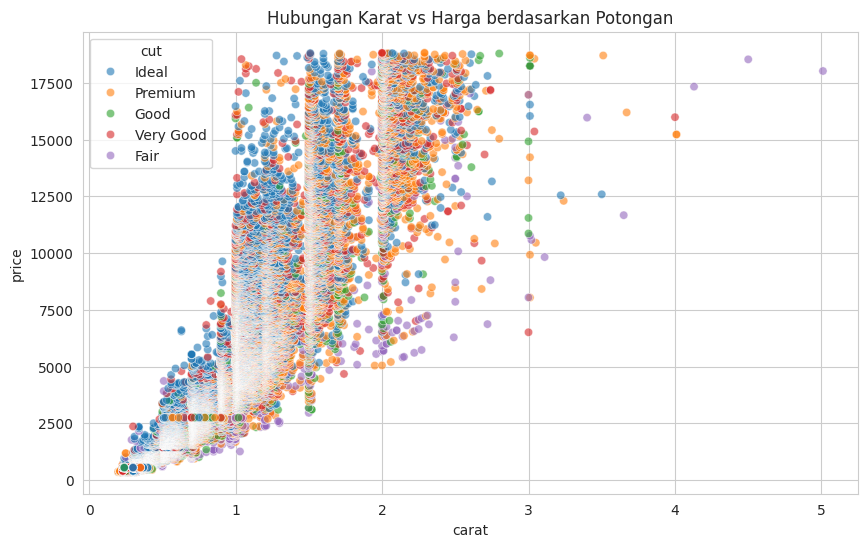

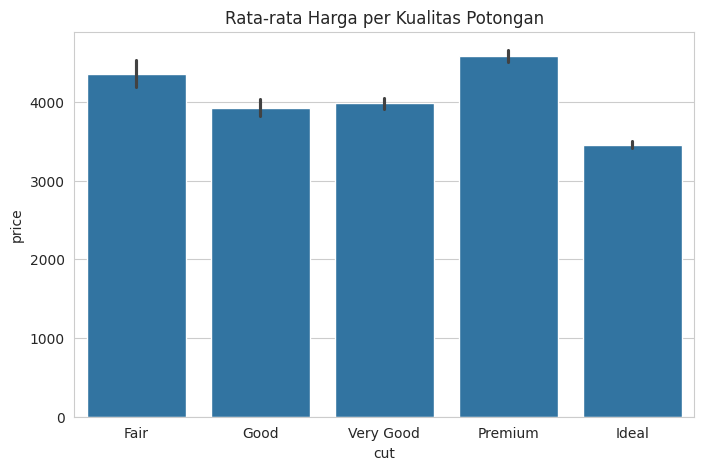

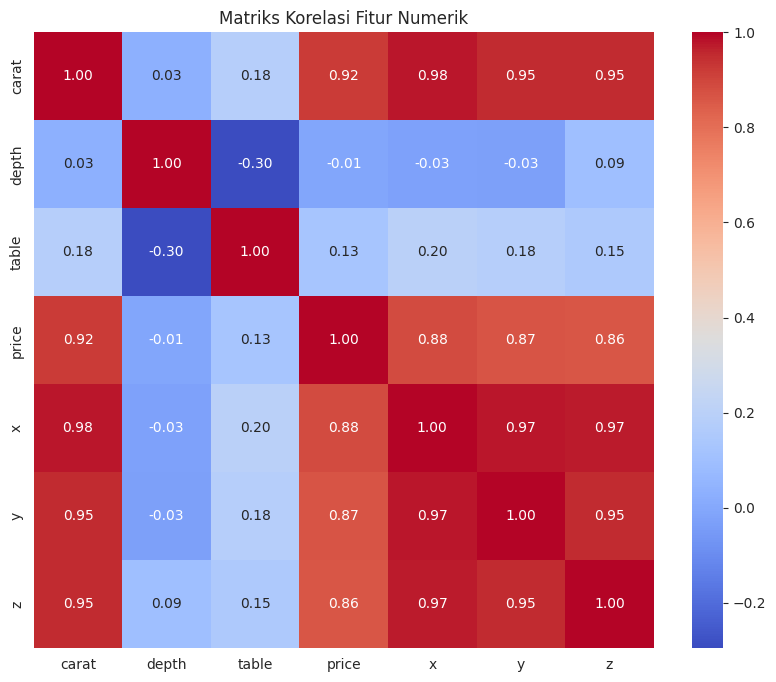

In [18]:
# 1. Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())

# 2. Distribusi harga
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribusi Harga Berlian')
plt.xlabel('Harga (USD)')
plt.show()

# 3. Hubungan carat vs price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='carat', y='price', hue='cut', alpha=0.6)
plt.title('Hubungan Karat vs Harga berdasarkan Potongan')
plt.show()

# 4. Rata-rata harga per cut
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='cut', y='price', order=['Fair','Good','Very Good','Premium','Ideal'])
plt.title('Rata-rata Harga per Kualitas Potongan')
plt.show()

# 5. Korelasi antar fitur numerik
plt.figure(figsize=(10,8))
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
# Cek dan hapus missing values
print("Missing values:", df.isnull().sum().sum())
df = df.dropna()

# Hapus duplikat
print("Duplikat dihapus:", df.duplicated().sum())
df = df.drop_duplicates()

# Hapus hanya outlier ekstrem (persentil 0.5 dan 99.5), karena ini dataset berlian
lower_bound = df['price'].quantile(0.005)
upper_bound = df['price'].quantile(0.995)
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Transformasi log pada target untuk mengurangi skewness
df['price_log'] = np.log1p(df['price'])

# Encoding ordinal untuk cut (Fair ke Ideal: 0-4)
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
df['cut_encoded'] = df['cut'].map(cut_order)

# Encoding ordinal untuk color (J ke D: 0-6)
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
df['color_encoded'] = df['color'].map(color_order)

# Encoding ordinal untuk clarity (I1 ke IF: 0-7)
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4,
                  'VVS2': 5, 'VVS1': 6, 'IF': 7}
df['clarity_encoded'] = df['clarity'].map(clarity_order)

# Feature engineering: volume berlian
df['volume'] = df['x'] * df['y'] * df['z']

# Feature engineering: harga per karat
df['price_per_carat'] = df['price'] / df['carat']

# Feature engineering: interaksi cut dan clarity
df['cut_clarity_score'] = df['cut_encoded'] * df['clarity_encoded']

# Standarisasi fitur numerik (kecuali target)
features_to_scale = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'price_per_carat']
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Hapus kolom asli yang sudah tidak diperlukan (opsional)
df = df.drop(['cut', 'color', 'clarity'], axis=1)


Missing values: 0
Duplikat dihapus: 0


In [20]:
# Tampilkan 5 baris pertama hasil preprocessing
print("\nHasil preprocessing (5 baris pertama):")
print(df.head())

# Tampilkan info dataset setelah preprocessing
print("\nInfo dataset setelah preprocessing:")
print(df.info())


Hasil preprocessing (5 baris pertama):
    Unnamed: 0     carat     depth     table  price         x         y  \
30          31 -1.211824 -1.222904 -0.203515    402 -1.558306 -1.505559   
31          32 -1.211824 -1.362643 -0.203515    402 -1.522203 -1.478988   
32          33 -1.211824 -0.733818  0.692333    402 -1.585382 -1.523273   
33          34 -1.211824 -1.572252  0.244409    402 -1.549280 -1.478988   
34          35 -1.211824  0.104616  0.244409    402 -1.630510 -1.567558   

           z  price_log  cut_encoded  color_encoded  clarity_encoded  \
30 -1.614608   5.998937            2              4                4   
31 -1.600270   5.998937            2              4                4   
32 -1.600270   5.998937            2              5                4   
33 -1.628945   5.998937            2              5                4   
34 -1.571595   5.998937            2              6                4   

      volume  price_per_carat  cut_clarity_score  
30 -1.175107        -1.13

In [22]:
# Simpan dataset yang sudah dipreprocessing ke file CSV baru
df.to_csv('diamonds_clean.csv', index=False)